<a href="https://colab.research.google.com/github/UROOJKHANdev/ARTIFICIAL_INTELLIGENCE-AND-DATA-SCIENCE-MODELS-/blob/main/K_MEANS_CLUSTERING_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("/content/Train.csv")
df


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A
...,...,...,...,...,...,...,...,...,...,...,...
8063,464018,Male,No,22,No,NaN,0.0,Low,7.0,Cat_1,D
8064,464685,Male,No,35,No,Executive,3.0,Low,4.0,Cat_4,D
8065,465406,Female,No,33,Yes,Healthcare,1.0,Low,1.0,Cat_6,D
8066,467299,Female,No,27,Yes,Healthcare,1.0,Low,4.0,Cat_6,B


In [3]:
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [4]:
df.shape

(8068, 11)

In [5]:
df.columns

Index(['ID', 'Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession',
       'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1',
       'Segmentation'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


In [7]:
df.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,140
Age,0
Graduated,78
Profession,124
Work_Experience,829
Spending_Score,0
Family_Size,335
Var_1,76


In [8]:
df['Work_Experience'] = df['Work_Experience'].fillna(
    df['Work_Experience'].median()
)

df['Family_Size'] = df['Family_Size'].fillna(
    df['Family_Size'].median()
)

In [9]:
df['Ever_Married'] = df['Ever_Married'].fillna(
    df['Ever_Married'].mode()[0]
)

df['Graduated'] = df['Graduated'].fillna(
    df['Graduated'].mode()[0]
)

df['Profession'] = df['Profession'].fillna(
    df['Profession'].mode()[0]
)

df['Var_1'] = df['Var_1'].fillna(
    df['Var_1'].mode()[0]
)

In [10]:
df.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,0
Age,0
Graduated,0
Profession,0
Work_Experience,0
Spending_Score,0
Family_Size,0
Var_1,0


In [11]:
df.describe()

,ID,Age,Work_Experience,Family_Size
count,8068.000000,8068.000000,8068.000000,8068.000000
mean,463479.214551,43.466906,2.472980,2.856346
std,2595.381232,16.711696,3.265248,1.499577
min,458982.000000,18.000000,0.000000,1.000000
25%,461240.750000,30.000000,0.000000,2.000000
50%,463472.500000,40.000000,1.000000,3.000000
75%,465744.250000,53.000000,4.000000,4.000000
max,467974.000000,89.000000,14.000000,9.000000


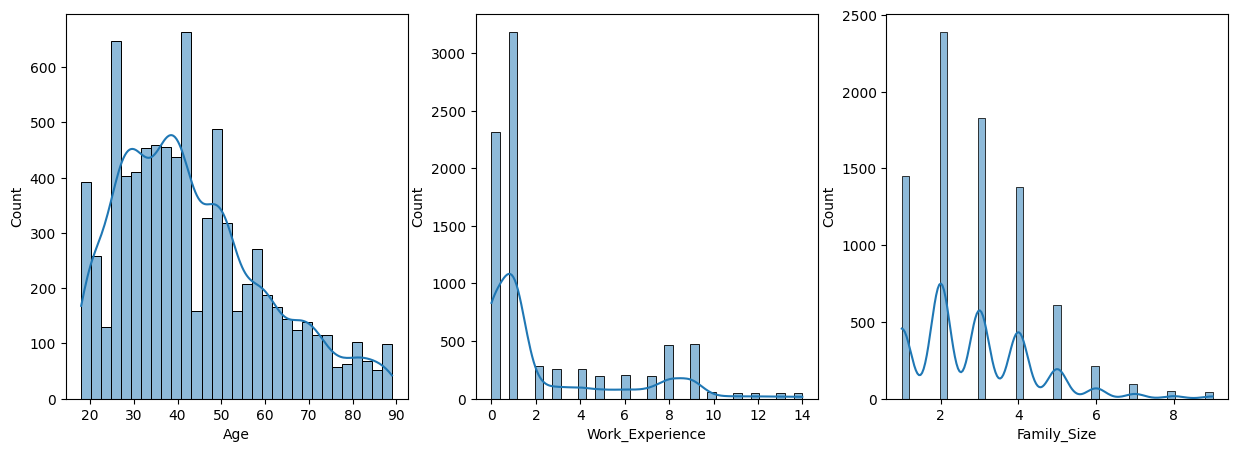

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(df['Age'], kde=True)

plt.subplot(1,3,2)
sns.histplot(df['Work_Experience'], kde=True)

plt.subplot(1,3,3)
sns.histplot(df['Family_Size'], kde=True)

plt.show()

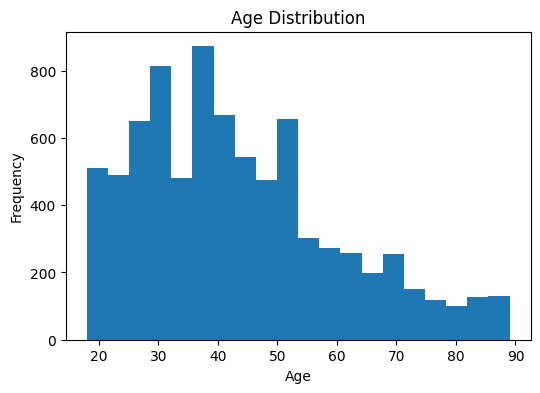

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.hist(df['Age'], bins=20)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

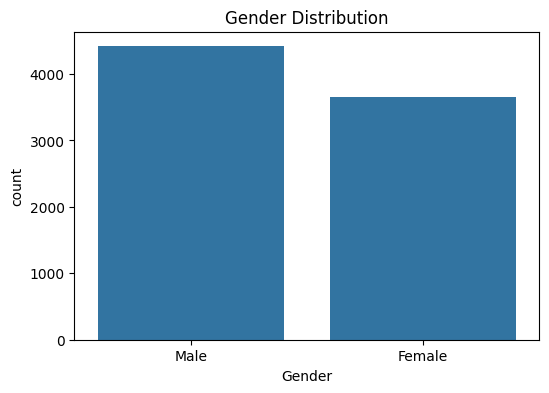

In [14]:
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution")

plt.show()

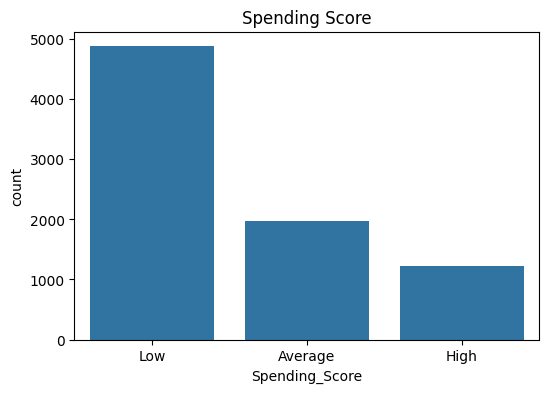

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(x='Spending_Score', data=df)

plt.title("Spending Score")

plt.show()

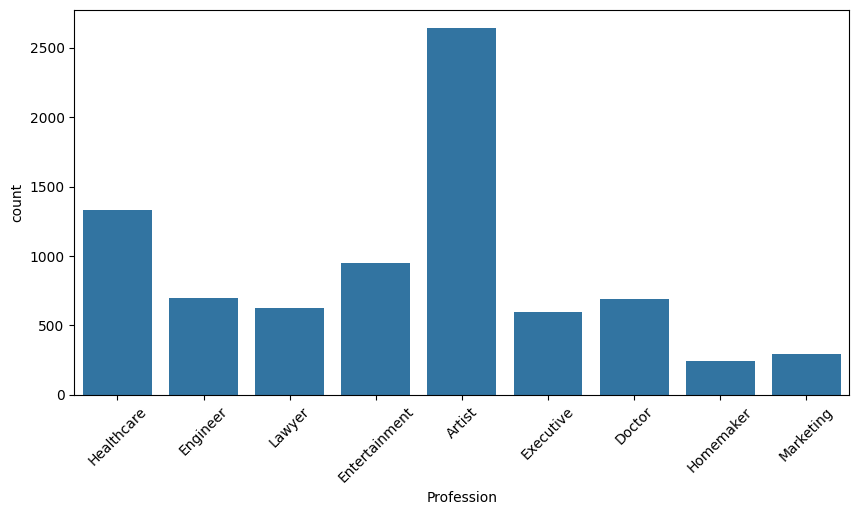

In [16]:
plt.figure(figsize=(10,5))

sns.countplot(x='Profession', data=df)

plt.xticks(rotation=45)

plt.show()

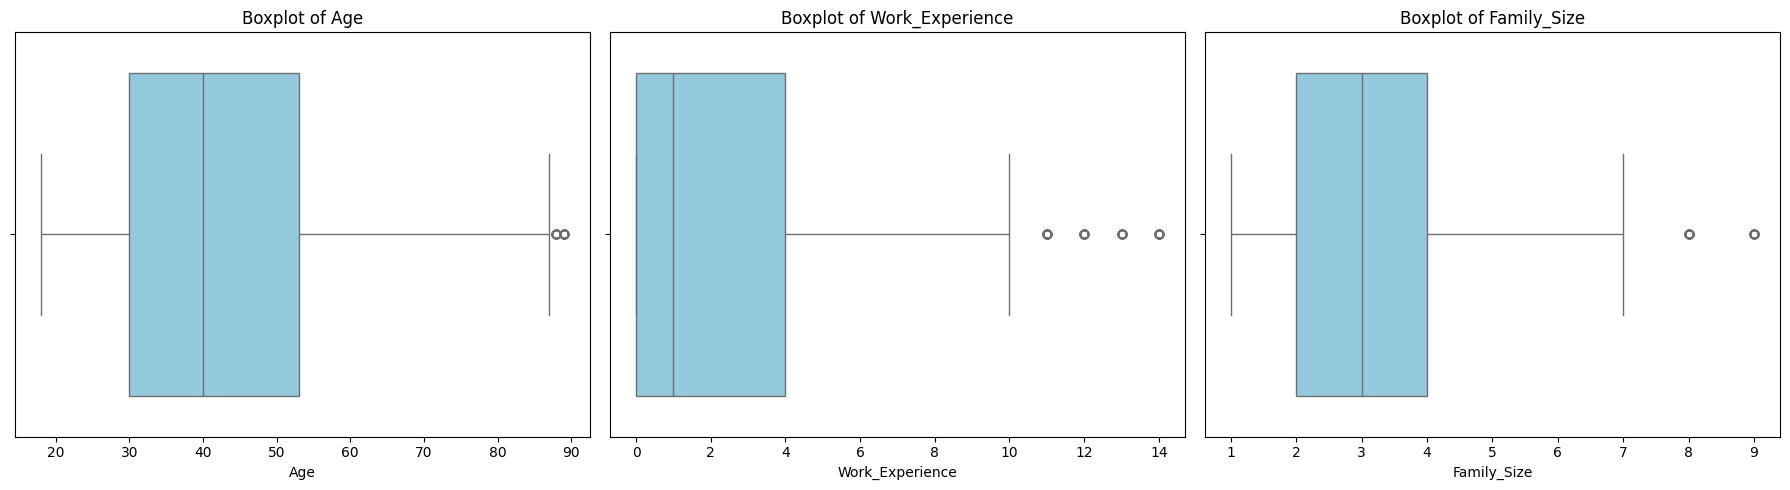

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns (ID ko exclude kar diya)
numerical_columns = ['Age', 'Work_Experience', 'Family_Size']

plt.figure(figsize=(18,5))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(1, len(numerical_columns), i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [18]:
numerical_columns = ['Age', 'Work_Experience', 'Family_Size']

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower_bound) &
        (df[col] <= upper_bound)
    ]

print("Shape after removing outliers:", df.shape)

Shape after removing outliers: (7720, 11)


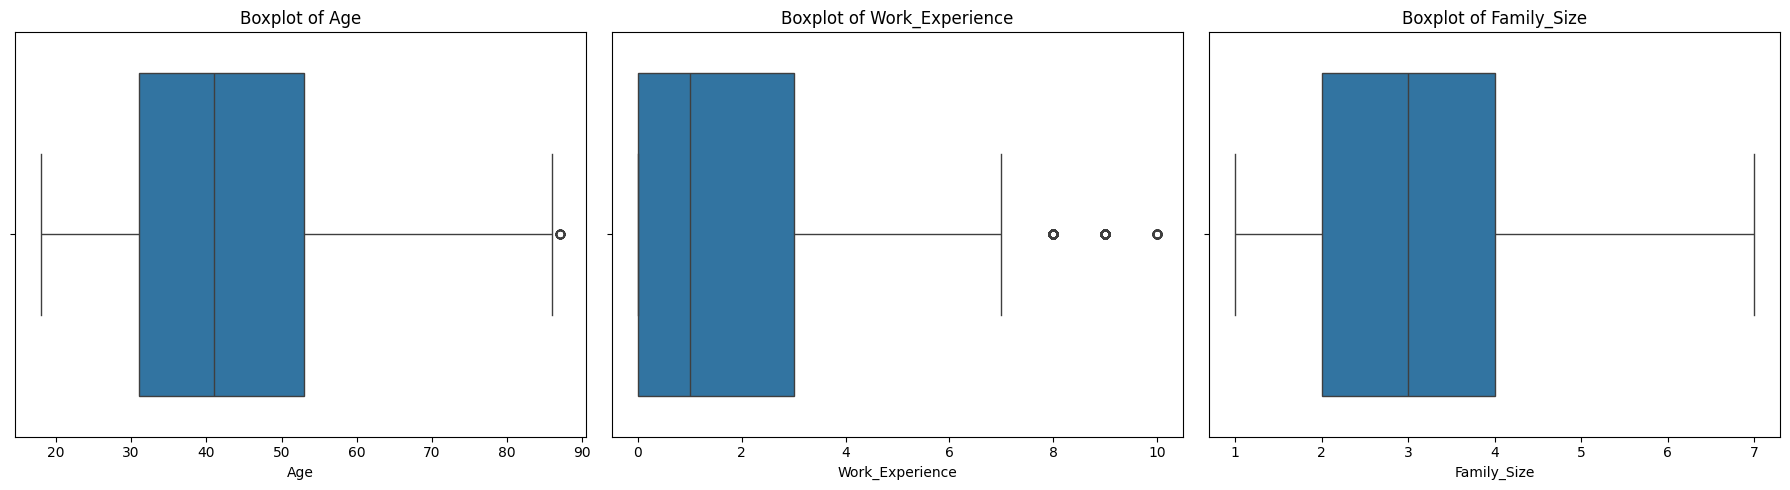

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_columns = ['Age', 'Work_Experience', 'Family_Size']

plt.figure(figsize=(18, 5))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(1, len(numerical_columns), i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

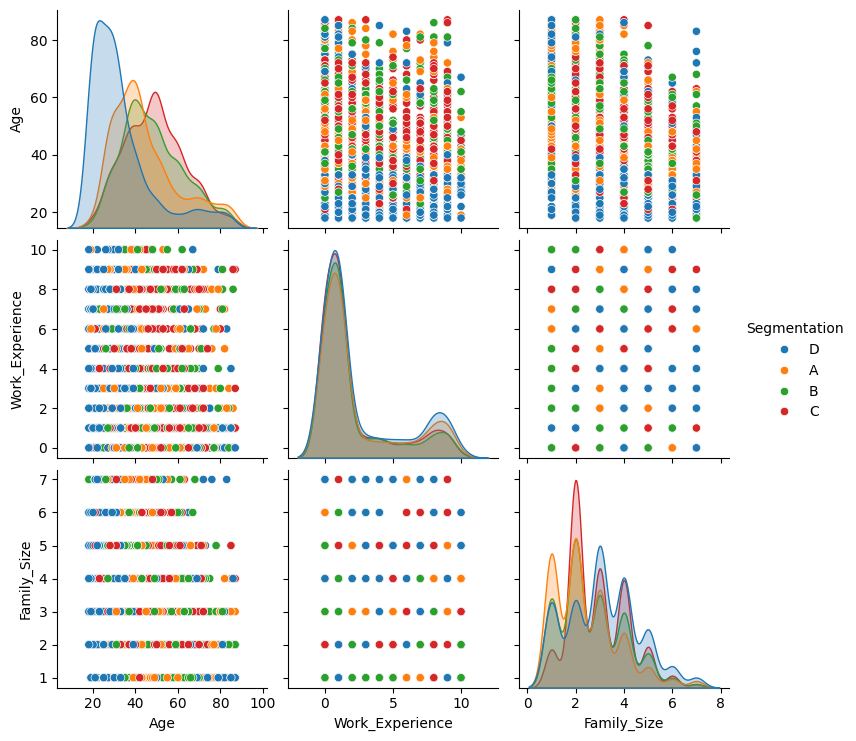

In [20]:
sns.pairplot(
    df,
    vars=['Age','Work_Experience','Family_Size'],
    hue='Segmentation'
)

plt.show()

In [21]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = encoder.fit_transform(df[col])

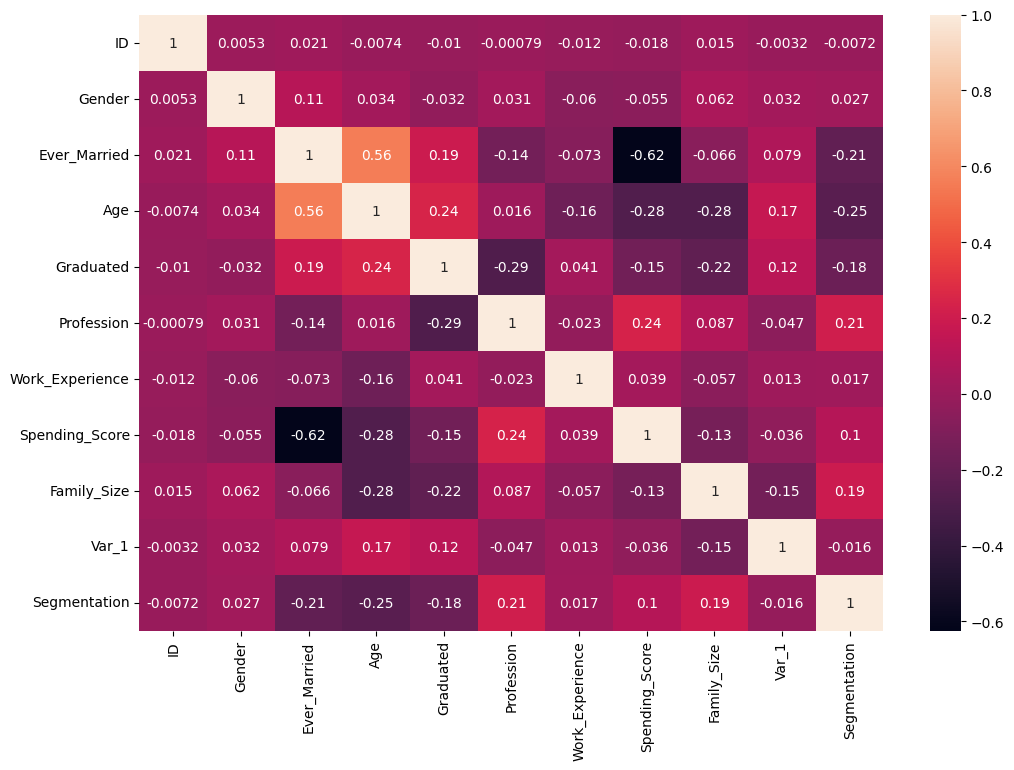

In [22]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True)

plt.show()

In [23]:
X = df.drop('Segmentation', axis=1)

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [25]:
print(X_scaled.shape)

(7720, 10)


In [26]:
from sklearn.cluster import KMeans

model = KMeans(
    n_clusters=4,
    random_state=42
)

print(model)

KMeans(n_clusters=4, random_state=42)


In [27]:
model.fit(X_scaled)

print("Model Training Completed Successfully!")

Model Training Completed Successfully!


In [28]:
clusters = model.labels_

print(clusters)

[0 1 2 ... 3 0 1]


In [29]:
df['Cluster'] = clusters

print(df.head())

       ID  Gender  Ever_Married  Age  Graduated  Profession  Work_Experience  \
0  462809       1             0   22          0           5              1.0   
1  462643       0             1   38          1           2              1.0   
2  466315       0             1   67          1           2              1.0   
3  461735       1             1   67          1           7              0.0   
4  462669       0             1   40          1           3              1.0   

   Spending_Score  Family_Size  Var_1  Segmentation  Cluster  
0               2          4.0      3             3        0  
1               0          3.0      3             0        1  
2               2          1.0      5             1        2  
3               1          2.0      5             1        2  
4               1          6.0      5             0        1  


In [30]:
print(df['Cluster'].value_counts())

Cluster
1    2458
3    2129
0    1974
2    1159
Name: count, dtype: int64


In [31]:
print(model.cluster_centers_)

[[ 0.02858187  0.00598201 -1.000118   -0.98481049 -0.87835606  0.56951277
  -0.04901096  0.72533496  0.73445574 -0.35239386]
 [ 0.02996122  0.08452688  0.82378747  0.21415593  0.28351954 -0.51469742
  -0.01678739 -1.28786795  0.27272694  0.00520701]
 [ 0.01187097  0.23957211  0.74818713  1.5300199  -0.12520307  1.02191063
  -0.39294986  0.13387173 -0.48974899  0.30808236]
 [-0.06750946 -0.23344303 -0.43135477 -0.16744471  0.55456143 -0.48963233
   0.27858728  0.7414724  -0.7285563   0.15277315]]


In [32]:
print(df.groupby('Cluster').mean())

                    ID    Gender  Ever_Married        Age  Graduated  \
Cluster                                                                
0        463558.716819  0.552178      0.104863  27.273556   0.204154   
1        463564.576485  0.591538      1.000000  46.823434   0.765256   
2        463517.544435  0.668680      0.962899  68.278689   0.567731   
3        463313.157351  0.433537      0.384218  40.608267   0.896195   

         Profession  Work_Experience  Spending_Score  Family_Size     Var_1  \
Cluster                                                                       
0          4.151469         2.102330        1.972644     3.819149  3.635765   
1          1.411310         2.197315        0.256713     3.183076  4.145647   
2          5.294219         1.100949        1.468507     2.132010  4.578085   
3          1.472992         3.059652        1.986379     1.802255  4.356036   

         Segmentation  
Cluster                
0            2.229483  
1            1.41537

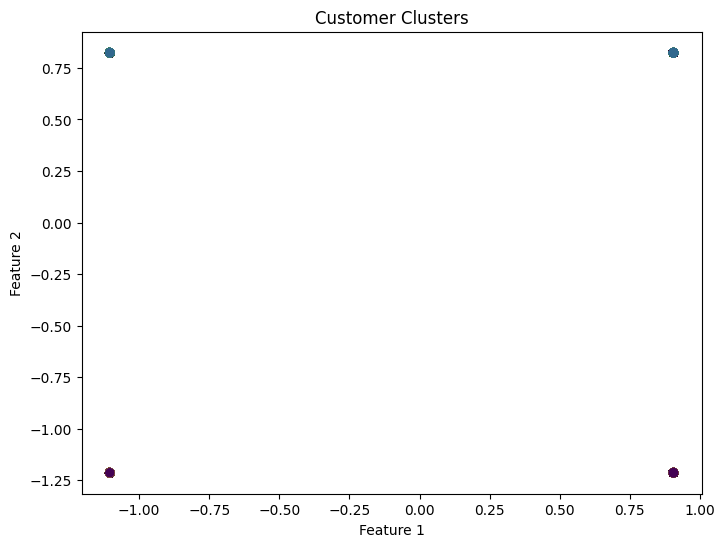

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,1],
    X_scaled[:,2],
    c=clusters,
    cmap='viridis'
)

plt.title("Customer Clusters")

plt.xlabel("Feature 1")

plt.ylabel("Feature 2")

plt.show()

In [34]:
print("Inertia:", model.inertia_)

Inertia: 52378.35898058592


In [35]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.16279075017588876


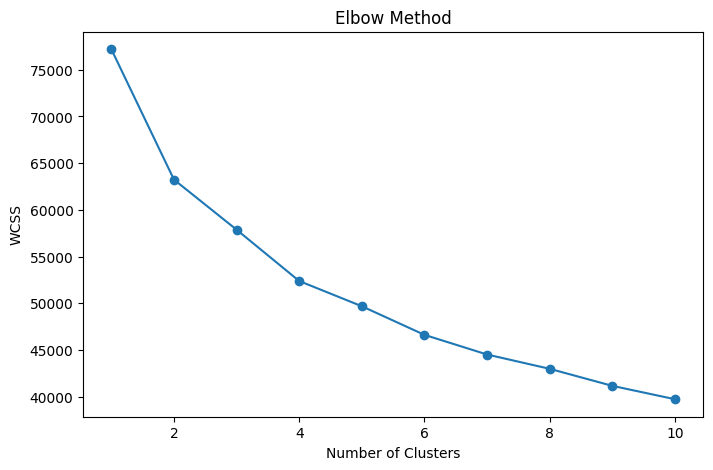

In [36]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [37]:
best_model = KMeans(
    n_clusters=4,
    random_state=42
)

best_model.fit(X_scaled)

df['Cluster'] = best_model.labels_

In [38]:
y_means = best_model.fit_predict(X_scaled)

In [39]:
df['Cluster'] = y_means

In [40]:
df[['Cluster']].head()

,Cluster
0,0
1,1
2,2
3,2
4,1


In [41]:
cluster_profile = df.groupby('Cluster').mean()

cluster_profile

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
Cluster,,,,,,,,,,,
0,463558.716819,0.552178,0.104863,27.273556,0.204154,4.151469,2.102330,1.972644,3.819149,3.635765,2.229483
1,463564.576485,0.591538,1.000000,46.823434,0.765256,1.411310,2.197315,0.256713,3.183076,4.145647,1.415378
2,463517.544435,0.668680,0.962899,68.278689,0.567731,5.294219,1.100949,1.468507,2.132010,4.578085,1.308887
3,463313.157351,0.433537,0.384218,40.608267,0.896195,1.472992,3.059652,1.986379,1.802255,4.356036,1.252701


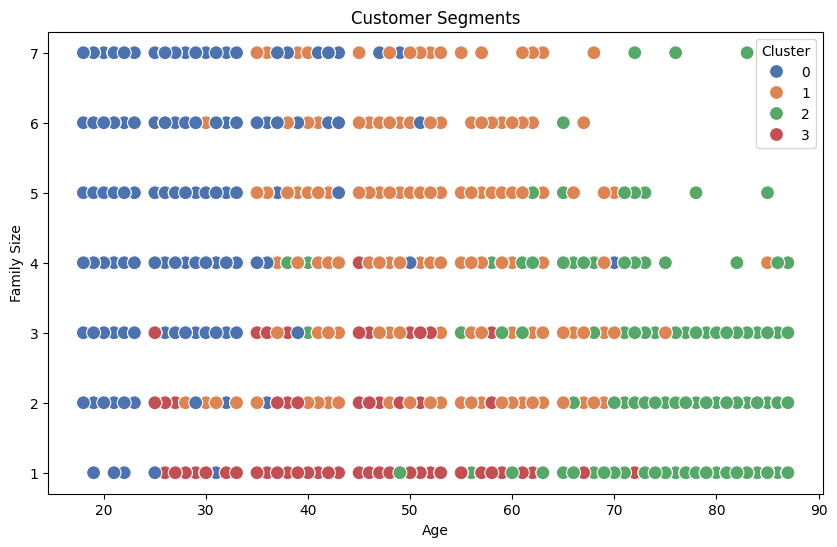

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['Age'],
    y=df['Family_Size'],
    hue=df['Cluster'],
    palette='deep',
    s=100
)

plt.title("Customer Segments")
plt.xlabel("Age")
plt.ylabel("Family Size")

plt.show()

In [43]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

best_score = -1
best_k = 2

for k in range(2,11):

    model = KMeans(n_clusters=k, random_state=42)

    model.fit(X_scaled)

    score = silhouette_score(X_scaled, model.labels_)

    print("K =", k, "Silhouette Score =", score)

    if score > best_score:
        best_score = score
        best_k = k

print("\nBest Number of Clusters:", best_k)
print("Best Silhouette Score:", best_score)

K = 2 Silhouette Score = 0.18052616581065348
K = 3 Silhouette Score = 0.14791210899469362
K = 4 Silhouette Score = 0.16279075017588876
K = 5 Silhouette Score = 0.15570856652713608
K = 6 Silhouette Score = 0.1571482279076687
K = 7 Silhouette Score = 0.14981366959334255
K = 8 Silhouette Score = 0.14529069084228138
K = 9 Silhouette Score = 0.1401279343275804
K = 10 Silhouette Score = 0.14236514226419414

Best Number of Clusters: 2
Best Silhouette Score: 0.18052616581065348


In [44]:
final_model = KMeans(
    n_clusters=best_k,
    random_state=42
)

final_model.fit(X_scaled)

KMeans(n_clusters=2, random_state=42)

In [45]:
df['Cluster'] = final_model.labels_

print(df.head())

       ID  Gender  Ever_Married  Age  Graduated  Profession  Work_Experience  \
0  462809       1             0   22          0           5              1.0   
1  462643       0             1   38          1           2              1.0   
2  466315       0             1   67          1           2              1.0   
3  461735       1             1   67          1           7              0.0   
4  462669       0             1   40          1           3              1.0   

   Spending_Score  Family_Size  Var_1  Segmentation  Cluster  
0               2          4.0      3             3        0  
1               0          3.0      3             0        1  
2               2          1.0      5             1        1  
3               1          2.0      5             1        1  
4               1          6.0      5             0        1  


In [46]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

pipeline = Pipeline([

    ('scaler', StandardScaler()),

    ('kmeans', KMeans(
        n_clusters=best_k,
        random_state=42
    ))

])

pipeline.fit(X)

Pipeline(steps=[('scaler', StandardScaler()),
                ('kmeans', KMeans(n_clusters=2, random_state=42))])

In [47]:
cluster = pipeline.predict(X)

print(cluster[:10])

[0 1 1 1 1 1 0 0 1 1]


In [48]:
import joblib

joblib.dump(pipeline, "kmeans_customer_segmentation.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [49]:
loaded_model = joblib.load("kmeans_customer_segmentation.pkl")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [50]:
prediction = loaded_model.predict(X.iloc[:5])

print(prediction)

[0 1 1 1 1]


In [51]:
print(df[['ID','Age','Profession','Cluster']].head(10))

       ID  Age  Profession  Cluster
0  462809   22           5        0
1  462643   38           2        1
2  466315   67           2        1
3  461735   67           7        1
4  462669   40           3        1
5  461319   56           0        1
6  460156   32           5        0
7  464347   33           5        0
8  465015   61           2        1
9  465176   55           0        1


In [52]:
df.to_csv("Customer_Segmentation_Result.csv", index=False)

print("Clustered Dataset Saved Successfully!")

Clustered Dataset Saved Successfully!
